<a href="https://colab.research.google.com/github/AnjiLakshmi12/6thSem-ML-Lab/blob/main/%E2%80%9C1BM24CS401_Lab_9_Kmeans_ipynb%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


## Load the Iris dataset

In [ ]:
df = pd.read_csv('/content/iris.csv.csv')
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Select features and apply scaling

We will use 'petal_width' and 'petal_length' as requested. Scaling is often beneficial for distance-based algorithms like K-Means to ensure all features contribute equally to the distance calculation.

In [ ]:
features = df[['petal_width', 'petal_length']]

# Apply StandardScaler for preprocessing
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Convert back to DataFrame for easier handling if needed, or keep as numpy array for KMeans
scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns)
display(scaled_features_df.head())

,petal_width,petal_length
0,-1.312977,-1.341272
1,-1.312977,-1.341272
2,-1.312977,-1.398138
3,-1.312977,-1.284407
4,-1.312977,-1.341272


## Draw an elbow plot to figure out the optimal value of k

The elbow method helps to determine the optimal number of clusters by looking at the 'elbow' point in the plot of inertia vs. number of clusters. Inertia is the sum of squared distances of samples to their closest cluster center.

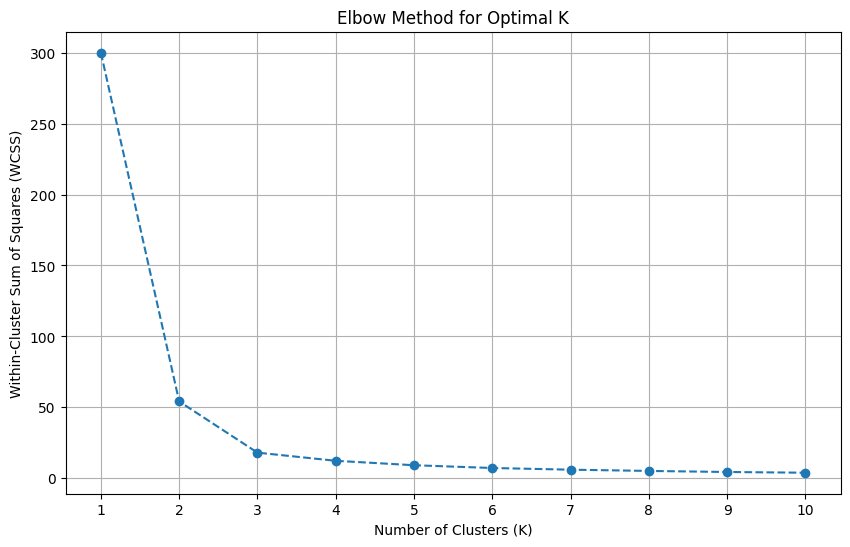

In [ ]:
wcss = [] # Within-cluster sum of squares

# Try different values of k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is set to suppress future warning
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Apply K-Means Clustering with Optimal K and Visualize Results

Now that we've determined the optimal number of clusters (k=3) using the elbow method, we will apply the K-Means algorithm with this value of k to cluster the dataset. We'll then visualize these clusters using a scatter plot.

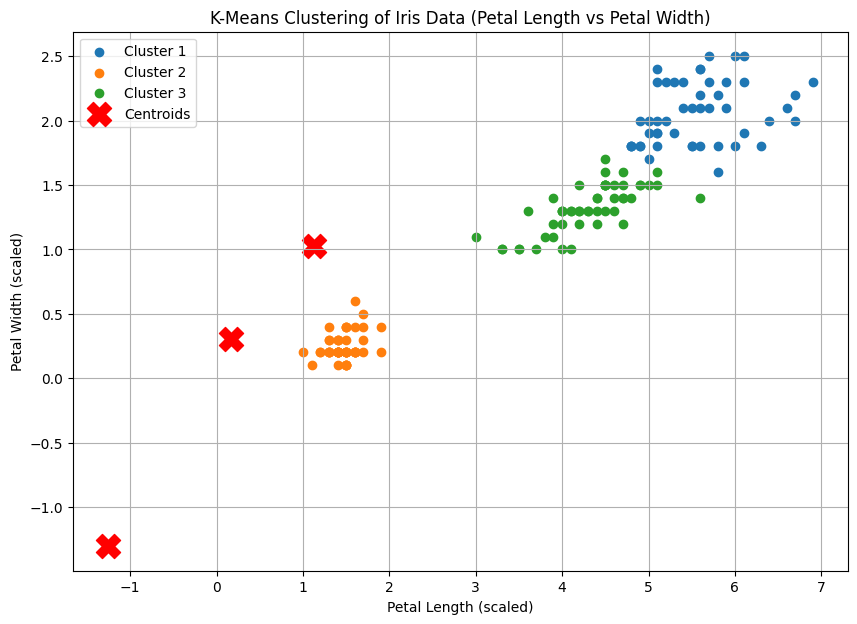

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1


In [ ]:
# Apply K-Means with k=3
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Add the cluster labels to the original DataFrame for easy visualization
df['cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 7))
for i in range(k):
    plt.scatter(df[df['cluster'] == i]['petal_length'],
                df[df['cluster'] == i]['petal_width'],
                label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering of Iris Data (Petal Length vs Petal Width)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.grid(True)
plt.show()

display(df.head())